In [1]:
import functions as fn
from mastu import HSV
import numpy as np
import sys

In [2]:
plot = True

In [3]:
### load the dictionary
dictFile = '/home/sthoma/tokamak_inversion_routines/Dictionaries/51347_experiment1.txt'
inputDict = fn.loadDict(dictFile)

### unzip the dictionary
shotn = inputDict['shotn']
Rzfile = inputDict['Rzfile']
maskFile = inputDict['maskFile']

### the inputs to select which bits of video, and averaging
I0 = inputDict['I0']
I1 = inputDict['I1']
J0 = inputDict['J0']
J1 = inputDict['J1']
tend = inputDict['tend']
raverage = inputDict['raverage']
taverage = inputDict['taverage']
# T0 = inputDict['T0']
# T1 = inputDict['T1']
T0 = 500
T1 = 510

### for converting to photons and account for vignetting
photons = bool(inputDict['photons'])
exposureMult = inputDict['exposureMult']
vignette = bool(inputDict['vignette'])

### variables for the inversion, should be approximately constant
saveFile = inputDict['saveFile']
rEnd = inputDict['rEnd']
rEnd = 1.55
nrMult = inputDict['nrMult']
sysErr = inputDict['sysErr']
photon = bool(inputDict['photon'])
biasedEdges = bool(inputDict['biasedEdges'])
nFisher = inputDict['nFisher']
regGuess = inputDict['regGuess']
regMin = inputDict['regMin']

### use pedestal fitting or raw Thomson
kindThomson = inputDict['kindThomson']
### R value pedestal fitting works up to
Rprofile0 = inputDict['Rprofile0']

### kind of interpolation to use, don't need to change
line = inputDict['line']
kindExcite = inputDict['kindExcite']
kindRecomb = inputDict['kindRecomb']
kindIonise = inputDict['kindIonise']

### using a constant percentage for profile error
percent = inputDict['percent']

### temperature to assume for neutral density from fig
figTemp = inputDict['figTemp']

In [4]:
print(regGuess)

0.7


In [5]:
nrMult = 1.
regGuess = 0.8

In [6]:
### load the Rz coordinates
R0, z0 = HSV.getRz(Rzfile, I0, I1, J0, J1)

### prepping R, adding extra, and flipping
R, goodChans, flipBool = fn.prepR(R0, rEnd)
### grid to interpolate onto
nGrid = int(len(R0) * nrMult)
Rgrid, RgridB = fn.makeGrid(R, nGrid)
### making dL
dL = fn.makeDL(Rgrid, R)

In [7]:
### quicker than loading the whole dataset
trange = HSV.makeTimeRange(shotn, T0, T1)
### load the data from UDA
rawData, time = HSV.get(shotn, trange=trange)

### 
dSlice = (slice(I0,I1), slice(J0,J1), slice(0,len(time)))
data, err = HSV.prepData(
    shotn, rawData, dSlice, goodChans, flipBool, 
    rEnd, tend, sysErr=sysErr, photon=photon
)
### average in space and time if wanted
if raverage:
    data = HSV.makeRadialAverage(data, raverage, rEnd)
    err = HSV.makeRadialAverage(err, raverage, rEnd)
if taverage:
    data = HSV.makeTimeAverage(data, taverage)
    err = HSV.makeTimeAverage(err, taverage)

# ### chop down to selected time range
# tSlice = slice(T0, T1)
# data = data[tSlice,:]
# err = err[tSlice,:]
# time = time[tSlice]

### convert to ph m^-2 sr^-1
if photons:
    data, err = HSV.applyCalibration(data, err, inputDict)

### convert to ph m^-2 sr^-1 s^-1
data, err = HSV.applyExposure(data, err, shotn, mult=exposureMult)

### apply vignette function
if vignette:
    data, err = HSV.applyVignette(
        data, err, inputDict, shotn, dSlice[:-1], flipBool, rEnd
    )

### sizes of data
nT, nR = data.shape
### scale so not working with large numbers
scale = fn.makeScale(data)

In [8]:
### load the mask if using one
try:
    mask = HSV.loadMask(maskFile, flipBool, rEnd)
except TypeError as e:
    print('No maskFile, not using a mask')
    mask = np.ones(data.shape[1]).astype(bool)

### make the regularisation band matrix
D = fn.regulMatrix(nGrid, biasedEdges=biasedEdges)
### making empty arrays for results
# emissivity = np.zeros((nT, nGrid-1))
# emissivityErr = np.zeros((nT, nGrid-1))
emissivity0 = np.zeros((nT, nGrid-1))
emissivity0Err = np.zeros((nT, nGrid-1))
emissivity = np.zeros((nT, nGrid-1))
emissivityErr = np.zeros((nT, nGrid-1))
chi2 = np.zeros(nT)
gamma = np.zeros(nT)
backprojection0 = np.zeros((nT, nR))
backprojection = np.zeros((nT, nR))
### empty arrays for measurements of the emissivity profile
emMax = np.zeros(nT)
emMaxR = np.zeros(nT)
emR0 = np.zeros(nT)
emR1 = np.zeros(nT)
emFWHM = np.zeros(nT)
emFWHMerr = np.zeros(nT)

### arrays of indices, used in each iteration
indLos = slice(0, nR)
indSpace = slice(0, nGrid-1)
### linspace, used in each iteration
# Q = np.linspace(0., 1., indLos.stop-indLos.start)
Q = np.linspace(0., 1., np.count_nonzero(mask))

### make R array for profiles.
### Rprofile needed later, Rind needed now
Rind = fn.findNearest(RgridB, Rprofile0)
Rprofile = RgridB[Rind:]

### iterate over the times
for i in range(nT):
    emissivity0[i,indSpace], emissivity0Err[i,indSpace], backprojection0[i,mask], \
        _, _ = fn.inversion(
            data[i][mask], err[i][mask], dL[mask,:], scale, nGrid, Q, D, 
            indLos, indSpace, nFisher=4, regGuess=0.7, regMin=regMin
    )
    emissivity[i,indSpace], emissivityErr[i,indSpace], backprojection[i,mask], \
        chi2[i], gamma[i] = fn.inversion(
            data[i][mask], err[i][mask], dL[mask,:], scale, nGrid, Q, D, 
            indLos, indSpace, nFisher=nFisher, regGuess=regGuess, regMin=regMin
    )

    ### multiply the answers by scale
    emissivity0[i] *= scale
    emissivity0Err[i] *= scale
    emissivity[i] *= scale
    emissivityErr[i] *= scale

    ### find the emissivity maximum and location
    emMax[i] = emissivity[i][Rind:].max()
    emMaxR[i] = Rprofile[emissivity[i][Rind:].argmax()]

    ### calculate the emissivity FWHM
    emR0[i], emR1[i] = fn.findPosition(
        Rprofile, emissivity[i][Rind:], 0.5, kind='linear'
    )
    emFWHM[i] = emR1[i] - emR0[i]
    emFWHMerr[i] = fn.findPositionErr(
        Rprofile, emissivity[i][Rind:], emissivityErr[i][Rind:],
        0.5, x0=emR0[i], x1=emR1[i], kind='linear'
    )

No maskFile, not using a mask


/home/sthoma/tokamak_inversion_routines/functions.py:196: RuntimeWarning: invalid value encountered in multiply
  backprojection = fit = np.dot(p*w, U.T) * err


In [9]:
print('done')

done


In [10]:
%matplotlib widget

In [11]:
import plotFunctions as pf

In [12]:
fills = pf.makeFills(mask, R)

In [13]:
xlim = [1.0, 1.6]

In [14]:
nrMult, nFisher

(1.0, 4)

In [15]:
import matplotlib.pyplot as plt

def plotInversion(
    R, data, err, RgridB, y, yErr, backprojection, time, Rmax, yMax, R0, R1, 
    fwhm, fwhmErr, fills, xlim=[0.2,1.875], savePath=None, close=False, 
    y0=None, y0Err=None, backprojection0=None, 
    ):
    for i in range(data.shape[0]):
        fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
        ax.plot(R, data[i], '-', c='k', zorder=3, label='raw RBA')
        ax.fill_between(
            R, data[i]-err[i], data[i]+err[i], color='k', alpha=0.2
        )
        ax.plot(RgridB, y[i], '-', c='C0', zorder=2, label='inversion')
        ax.fill_between(
            RgridB, y[i]-yErr[i], y[i]+yErr[i], color='C0', alpha=0.2, zorder=2
        )
        ax.plot(R, backprojection[i,:], c='C2', zorder=4, label='reconst. RBA')
        ax.plot([R0[i], R1[i]], [yMax[i]/2., yMax[i]/2.], '-k', lw=0.8)
        ax.text(
            Rmax[i]*0.99, yMax[i], f'$R_\\mathrm{{max}}$\n{Rmax[i]:.3f}m', 
            ha='right', va='center', fontsize=8
        )
        ax.text(
            R1[i]*1.01, yMax[i]/2., 
            f'FWHM\n{fwhm[i]*100:.2f}$\\pm$\n{fwhmErr[i]*100:.2f}cm', 
            ha='left', va='center', fontsize=8
        )
        ax.set_xlim(xlim)
        # ylim = ax.get_ylim()
        x0 = fn.findNearest(RgridB, xlim[0])
        x1 = fn.findNearest(RgridB, xlim[1])
        ylim = [
            (y[i,x0:x1]-yErr[i,x0:x1]).min(), 
            (y[i,x0:x1]+yErr[i,x0:x1]).max() * 1.1
        ]
        if ylim[0] < 0:
            ylim[0] = ylim[0] * 2.
        else:
            ylim[0] = 0.
        ax.set_ylim(ylim)
        
        if y0 is not None:
            ax.plot(RgridB, y0[i], '-', c='C1', zorder=2, label='inversion0')
            ax.fill_between(
                RgridB, y0[i]-y0Err[i], y0[i]+y0Err[i], color='C1', alpha=0.2, zorder=2
            )
            ax.plot(R, backprojection0[i,:], c='C3', zorder=4, label='reconst.0 RBA')
        
        for j in range(0, fills.shape[0]):
            ax.fill_between(
                fills[j], [ylim[0],ylim[0]], 
                [ylim[1],ylim[1]], color='C3', alpha=0.2
            )
        ax.plot(xlim, [0.,0.], '-k', lw=0.8, zorder=1)
        ax.set_xlabel('R (m)', fontsize=9)
        ax.set_ylabel('Units', fontsize=9)
        ax.yaxis.get_offset_text().set_size(9)
        ax.legend(fancybox=1, framealpha=1, fontsize=8)
        ax.tick_params(
            axis="both", which='both', labelsize=9, direction='in', 
                    left=True, bottom=True, right=True, top=True
        )
        ax.set_title(f'i={i:.0f}, t={time[i]:.4f}s', fontsize=10)
        plt.tight_layout()
        if savePath:
            plt.savefig(savePath + f'{time[i]:.4f}s.png')
        if close:
            plt.close()
    return

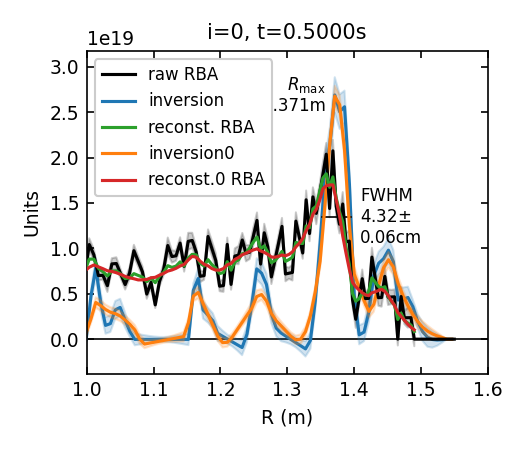

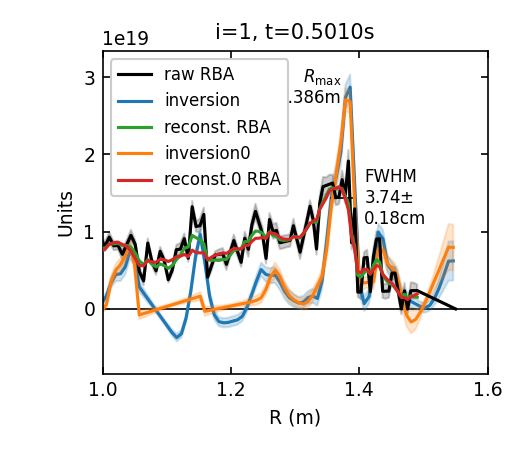

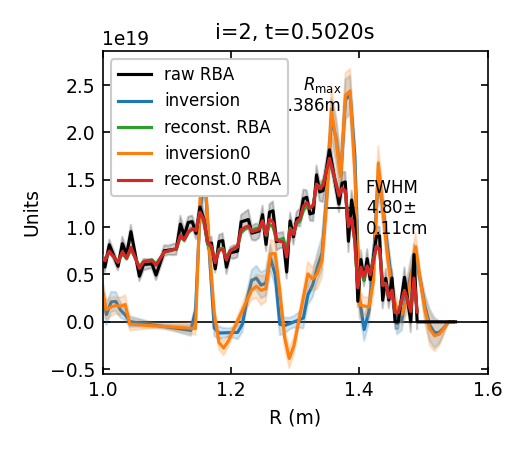

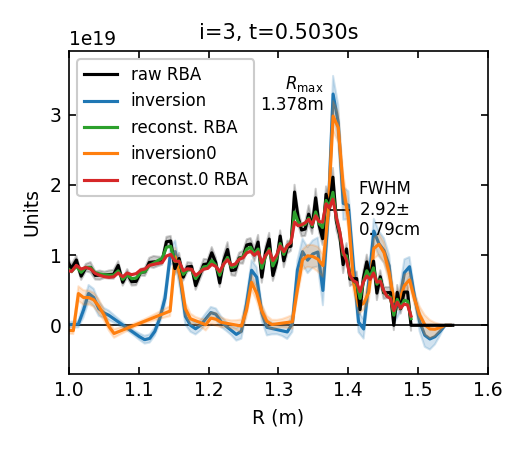

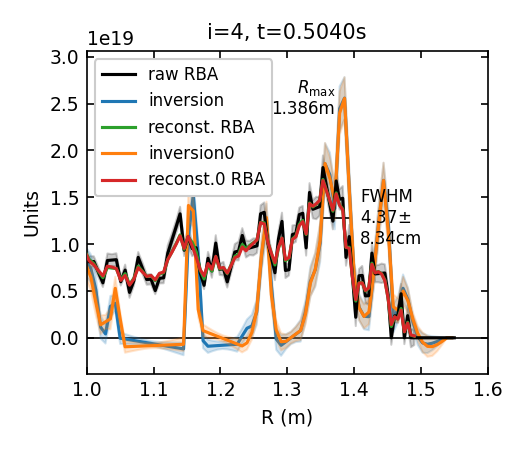

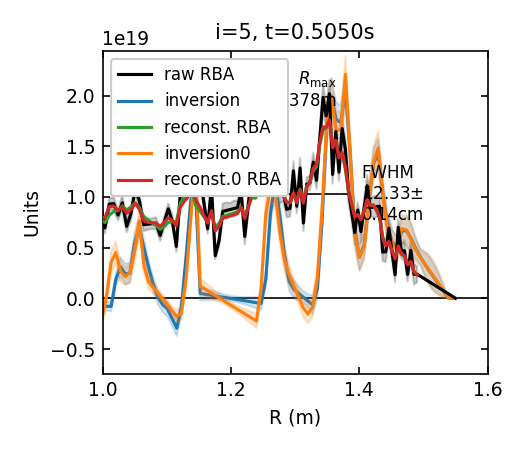

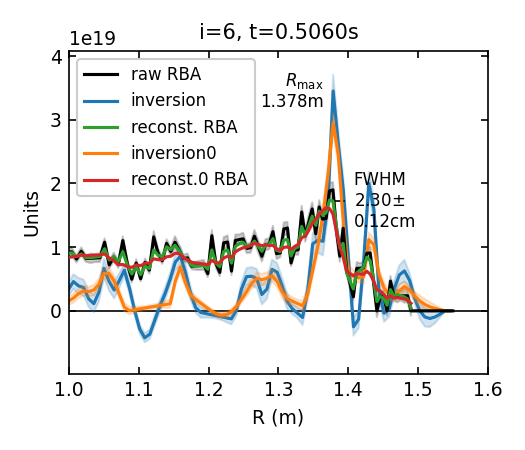

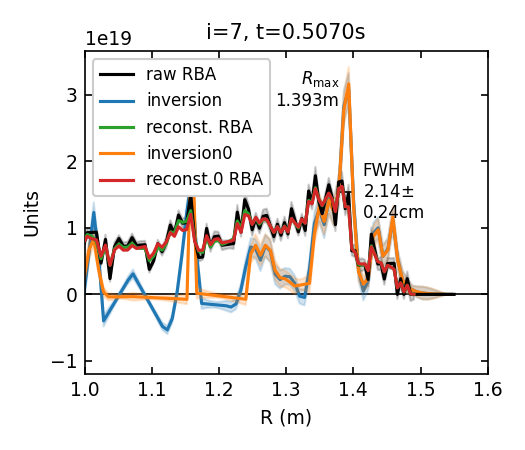

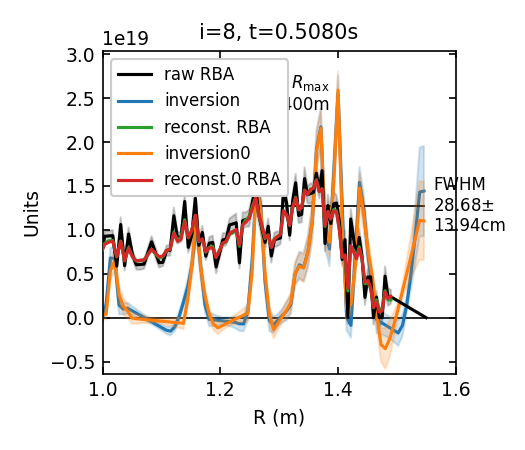

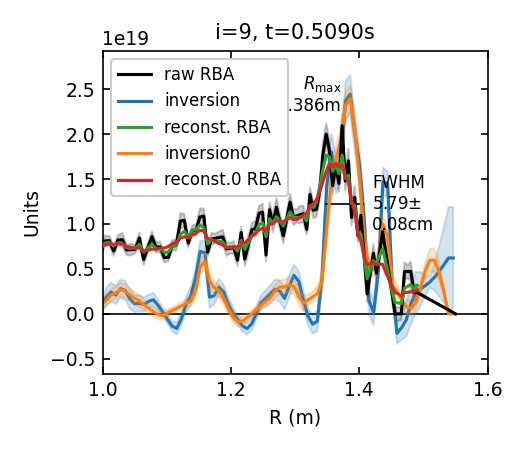

In [16]:
plotInversion(
    R, data, err, RgridB, emissivity, emissivityErr, backprojection, time,
    emMaxR, emMax, emR0, emR1, emFWHM, emFWHMerr, fills, xlim=xlim, 
    y0=emissivity0, y0Err=emissivity0Err, backprojection0=backprojection0
)

In [17]:
np.isclose(emissivity, emissivity0).all(), np.isclose(emissivity0, emissivity).all()

(False, False)

In [19]:
regGuess

0.8